In [2]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from adjustText import adjust_text

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)
 

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


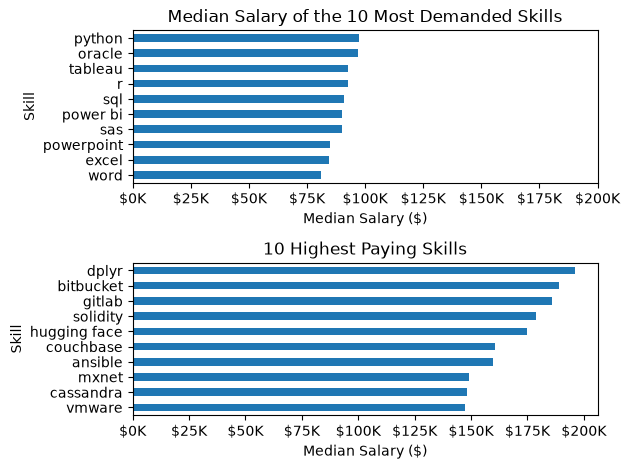

In [4]:
fig, ax = plt.subplots(2, 1)

Needed = df[(df['job_title_short'] == 'Data Analyst') &(df['job_country'] == 'United States')].copy()
Needed = Needed.explode('job_skills')

Demand = ( Needed.dropna(subset=['job_skills']).groupby('job_skills').size().sort_values(ascending=False).head(10))
DemandSalary = (Needed.dropna(subset=['job_skills']).groupby('job_skills')['salary_year_avg'].median().loc[Demand.index].sort_values())
DemandSalary.plot(kind='barh',ax=ax[0],xlim = (0,200000))

ax[0].set_title('Median Salary of the 10 Most Demanded Skills')
ax[0].set_xlabel('Median Salary ($)')
ax[0].set_ylabel('Skill')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _ : f'${int(x/1000)}K'))

Pay = (Needed.dropna(subset=['job_skills']).groupby('job_skills')['salary_year_avg'].median().sort_values(ascending=False).head(10).sort_values())
Pay.plot(kind='barh',ax=ax[1])

ax[1].set_title('10 Highest Paying Skills')
ax[1].set_xlabel('Median Salary ($)')
ax[1].set_ylabel('Skill')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _ : f'${int(x/1000)}K'))
plt.tight_layout()
plt.show()
